In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, laplace, poisson, binom, cauchy, gamma, beta, chi2
from scipy.stats import cosine, lognorm, skew, kurtosis, gaussian_kde, mode, expon, ks_2samp
from scipy.stats import mannwhitneyu, ranksums, wilcoxon, anderson, shapiro, ttest_ind, ttest_1samp, f
plt.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})

<br><br>
ZADATAK 2. Дат jе интеграл: I=$\int_{0}^{20} \frac{x^3}{e^x-1}$, чиjи jе аналитички резултат познат: I=$\frac{\pi ^4}{15}$.<br>

a) Методом Монте Карло (униформно узорковање) проценити I за N = 10000.<br>
Упоредити са аналитичким резултатом и кратко коментарисати.

In [26]:
np.random.seed(1)                   # ovo nam posle svakog pokretanja omogucava iste random vrednosti
N = 10000                           # broj gadjanja

def f(x):
    return x**3/(np.exp(x)-1)

x = np.random.uniform(0,20,N)       # rand N brojeva od 0 do 20 (svi su jednako moguci,zato uniform)

# vidi vezbu 2 !!!!!!!!  ovo je ta MC metoda:
# 20 = 20 - 0 (granice integrala)
# mean jer formula ide 1/n * Suma(xi), sto je zapravo mean
I_MC = 20*np.mean(f(x))             # resenje integrala MC metodom   

I_exact = np.pi**4/15               # analiticko resenje

print("Monte Carlo =", I_MC)
print("Tacna vrednost =", I_exact)
print("Relativna greska =", abs(I_MC-I_exact)/I_exact)

Monte Carlo = 6.5581277183151805
Tacna vrednost = 6.493939402266828
Relativna greska = 0.00988434170265685


Komentar: za N smo uzeli $10^5$, sto je relativno veliki broj, pa je greska jako mala.

<br>б) За N ∈ {$10^2 , 10^3 , 10^4 , 10^5$} проценити σМК користећи 500 понављања за свако N . <br>
Исплотовати σМК(N) у лог-лог скали. Проверити да ли важи σМК (N ) ∝ $N ^{−1/2}$.<br>
Коментарисати

In [27]:
# Sta zadatak trazi:
# Za razne N (brojeve gadjanja) videti koliko rezultat varira, tj. koliko je postojan.
# To koliko je postojan/precizan/konzistentan ce nam reci σМК (std devijacija MK metode). 
# Sto je ta vrednost manja, to su resenja medjusobno slicnija (resenja tih 500 ponavljanja za svako N).
# To je kao da 500 puta meris jednu isti stvar pa ako se tvoja merenja maaalo razikuju medjuobno, to je super.

np.random.seed(1)
N_values = [100,1000,10000,100000]              # koliko gadjanja 

sigma_MC = []                                   # ovde storujemo dobijene sigma, da ih posle plotujemo 

for N in N_values:                              # isto radimo za 100, 1000, ... 100000 gadjanja (uzoraka)

    estimates = []                              # ovde storujemo rezultate integrala

    for i in range(500):                           # za svako N radimo po 500 ponavljanja (kao merimo duzinu stola 500 puta)

        x = np.random.uniform(0,20,N)              # rand N brojeva od 0 do 20 (svi su jednako moguci,zato uniform)

        I = 20*np.mean(f(x))                       # integral MK metodom, detaljnije gore

        estimates.append(I)                        # dodajemo u niz rezultata. Iz ovog niza dobijamo kasnije std. dev. σМК

    sigma_MC.append(np.std(estimates))             # std. dev. se nam racuna funkcija najjace, i dodaje u niz std. dev.

sigma_MC = np.array(sigma_MC)                      # ovo radimo zbog plotovanja
print(N_values)
print(sigma_MC)

[100, 1000, 10000, 100000]
[0.98636764 0.28663758 0.08946425 0.02868799]


Vidimo kako su σМК sve manje i manje! Zasto?? Zato sto sto vise gadjanja radimo (sto je N vece), to su onih 500 merenja medjusobno slicniji!

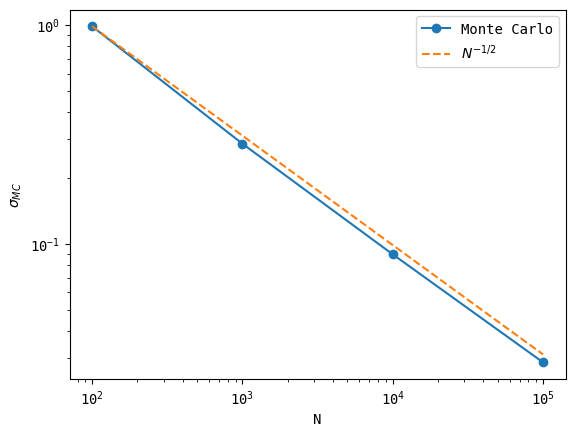

In [28]:
plt.figure()

plt.loglog(N_values, sigma_MC,'o-',label='Monte Carlo')
plt.loglog(N_values, sigma_MC[0]*(np.array(N_values)/N_values[0])**(-0.5), '--', label=r'$N^{-1/2}$')  
plt.xlabel("N")
plt.ylabel(r"$\sigma_{MC}$")
plt.legend()

plt.show()

Ovde je valjda dovoljno da vizuelno vidimo da li nas MK prati $N ^{−1/2}$

<br><br>
ZADATAK 3. Траjање блескова гама-зрачења (GRB) мери се величином $T_{90}$ (период за коjи се емитуjе 90% енергиjе блеска) и прати лог-нормалну расподелу. Нека постоjе две популациjе: кратки GRB ($T_{90}$ < 2 s) и дуги GRB ($T_{90}$ > 2 s).

а) Генерисати следеће узорке:<br>
• кратки GRB: $n_1$ = 80, $log_{10}$ ($T_{90}$} ) ∼ N (µ = −0.5, σ = 0.5),<br>
• дуги GRB: $n_2$ = 120, $log_{10}$ ($T_{90}$ ) ∼ N (µ = 1.5, σ = 0.6).

На jедном графику приказати хистограме $log_{10}$ ($T_{90}$ ) за обе популациjе. Означити вертикалну линиjу на $log_{10}$(2) ≈ 0.3.

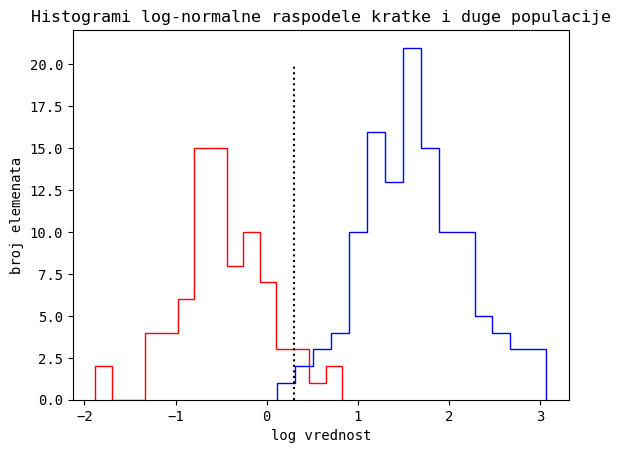

In [34]:
# Log-normalna raspodela zvuci zbunjujuce ali moze da se ignorise (kao da pise samo "normalna raspodela")
# jer je navedeno da log(T) ~ N tkd to je vec reseno

nx = 80             # broj uzoraka kratkih
ny = 120            # broj uzoraka dugih 

log_x = np.random.normal(-0.5, 0.5, nx)     # raspodela
log_y = np.random.normal(1.5, 0.6, ny)      # raspodela

plt.figure()
plt.hist(log_x, bins=15, color='red', histtype="step", label="Kratki GRB: log(x)")
plt.hist(log_y, bins=15, color='blue', histtype="step",  label="Dugi GRB: log(y)")
plt.plot([0.3, 0.3], [0, 20], ls=':', color='black')
plt.title("Histogrami log-normalne raspodele kratke i duge populacije")
plt.xlabel("log vrednost")
plt.ylabel("broj elemenata")
plt.show()

б) Тестирати нормалност $log_{10}$ ($T_{90}$) за обе класе, користећи Шапиро-Вилксов тест (α = 0.05). Интерпретирати. Да ли би било оправдано радити t-тест и зашто?

In [41]:
# Sapiro-Vilksov test proverava da li je raspodela normalna (brt bukv pise u zadatku da je normalna)

print(shapiro(log_x))
print(shapiro(log_y))

print(ttest_ind(log_x, log_y))

ShapiroResult(statistic=0.9851397083810534, pvalue=0.48268823249794174)
ShapiroResult(statistic=0.9911880554240281, pvalue=0.6441285973934849)
TtestResult(statistic=-26.237239969991254, pvalue=2.3024577274824192e-66, df=198.0)


Kratki GRB (logx): uzorak prati normalnu raspodelu (p>α) <br>
Dugi GRB (logy):   uzorak prati normalnu raspodelu (p>α)   

T-test koristiimo da saznamo da li si uzorci izvuceni iz normalnih raspodela sa istim  $\mu$. Mozemo ga koristiti, posto su raspodele normalne, sto t-test i zahteva, ali to nema smisla raditi jer vec znamo da su $\mu_x$ i $\mu_y$ veoma razliciti.

в) Применити двоузорачки Колмогоров-Смирнов тест и коментарисати.

In [45]:
# K-S test poredi cele raspodele (ocigledno nisu iste, jesu oba iz N ali su parametri mnogo drugaciji)

print(ks_2samp(log_x, log_y))

KstestResult(statistic=0.9416666666666667, pvalue=2.7278177954361496e-47, statistic_location=0.5784640896839928, statistic_sign=1)


Kako je i ocekivano, p vrednost je jako mala, ove dve populacije ne poticu iz iste raspodele

г) Применити U-тест и коментарисати.

In [43]:
print(mannwhitneyu(log_x, log_y))

MannwhitneyuResult(statistic=30.0, pvalue=1.2708797627525316e-32)


U-test nam daje malu p-vrednost, sto znaci da uzorci ne poticu iz iste raspodele.